In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import json


from tether_script import process_single_file

### Goal
* Try to decouple the velocity from the threshold parameter. When reaching faster velocities, the dt parameter becomes very small and the threshold gets very big. In the other sens, when retracting very small, the threshold becomes very small. 

* Normalize the threshold parameter by the velocity

### Get sessions and plateau analysis files
- df_sessions is the csv that contains the settings parameters for analyzing the tethers
- df_pl_data is the output data of the find_plateaus from tether_script.py

- df_merged, merges the two dataframes above, into one with the designated filename

In [2]:

# open Tether analysis summary csv to dataframe
df_sessions = pd.read_csv('/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/latest/test/tether_session_20250716_192549.csv')
df_pl_data = pd.read_csv('/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/latest/test/batch_analysis_results/detailed_plateau_data.csv')

# write function that will merge both dataframes by matching the filenames and creating a new dataframe from the merged data
# Standardize the filename column in both dataframes for merging
df_sessions['filename'] = df_sessions['file_name']
df_pl_data['filename'] = df_pl_data['filename']

# Merge on the standardized 'filename' column
df_merged = pd.merge(df_sessions, df_pl_data, on='filename', how='inner')

# #iterate through file_parameters in df_merged and run process_single_file for each file 
# for index, row in df_merged.iterrows():
#     file_parameters = row['file_parameters']
#     parameters = json.loads(file_parameters)
#     local_file_path = row['local_file_path']

# find a filename and get column details from df_merged
filename = 'fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.19.87.tdms'
row = df_merged[df_merged['filename'] == filename]

file_parameters = row['file_parameters'][0]
parameters = json.loads(file_parameters)
local_file_path = row['local_file_path'][0]


# print details of filename
print(f"Filename: {filename}")
for k, v in parameters.items():
    print(f"{k}: {v}")
print(f"Local File Path: {local_file_path}")


Filename: fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.19.87.tdms
sav_window_length: 24
sav_polyorder: 5
pl_threshold: 1.5000000000000002e-07
pl_min_width: 5
last_num_plateaus: 7
last_plateau_avg_percentage: 15
max_offset: 100
min_offset: 70
z_sensor_delay: 0.001
bool_correct_overshoot: True
Local File Path: /Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/300/fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.19.87.tdms


In [3]:
# Run process_single_file with the parameters and local file path
results = process_single_file(local_file_path, params=parameters)

# Extract the results
df_plat = results['df_plat']
df_data = results['df_data']


Processing file: fcurve_thp1_cell1_ret_300ums__2025.07.01_16.49.19.87.tdms
decimation: [10 10 10]
z_sensor_delay: 0.001, bool_correct_overshoot: True 
points removed : 50
start_indices: [    0 45762 46827]
end_indices: [45762 46827 55911]
NumPnts: [45762  1065  9084]
Deflection Length: 55863, Height: 55863
0 45762
segment relative position: 45762, segment duration: 0.915246
App
overshoot in the approach, accounted for   
removed overshoot
---------------------
46790 47854
segment relative position: 1064, segment duration: 0.021314774999999998
Con
---------------------
46827 55863
segment relative position: 9036, segment duration: 0.1816992
Ret
---------------------
  Found 7 plateaus


Text(0, 0.5, 'Force (N)')

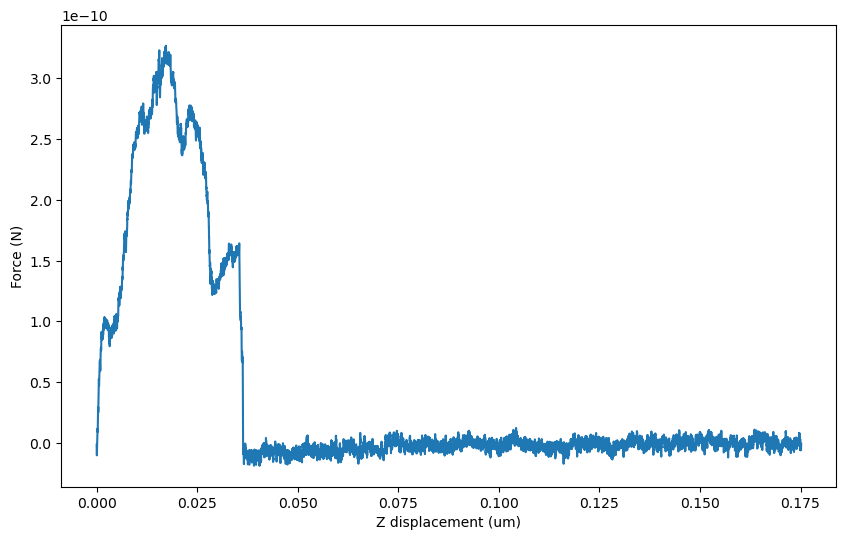

In [4]:
# plot data frame
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 6))
plt.plot(df_data['dt'], df_data['y'], label='Displacement')
# plt.plot(df_data['dt'], df_data['dy_abs_sav'], label='Savitzky-Golay Smoothed Displacement')
plt.xlabel('Z displacement (um)')
plt.ylabel('Force (N)')         

Plateau Threshold: 1.5000000000000002e-07


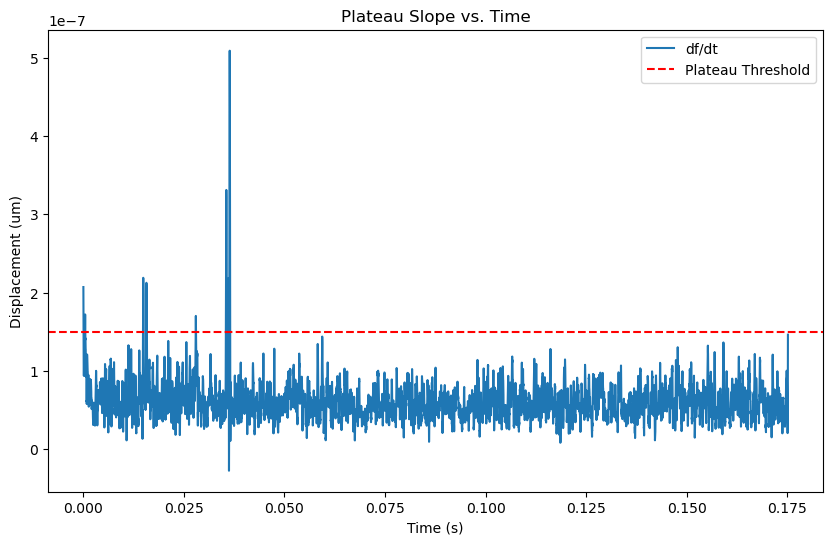

In [5]:
pl_threshold = parameters['pl_threshold']
print (f"Plateau Threshold: {pl_threshold}")
plt.figure(figsize=(10, 6))
plt.plot(df_data['dt'], df_data['dy_abs_sav'], label='df/dt')
plt.axhline(y=pl_threshold, color='r', linestyle='--', label='Plateau Threshold')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (um)')
plt.title('Plateau Slope vs. Time')
plt.legend()